# RetailRocket EDA

## Objective

This notebook provides a lightweight exploratory analysis of the processed RetailRocket interaction data used throughout the project. The goal is to summarize dataset shape, sparsity, event composition, and temporal coverage, then connect those properties to the repository's recommendation modeling results.


## Load Processed Data


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path("../data/processed")

interactions = pd.read_parquet(DATA_DIR / "interactions.parquet")
train = pd.read_parquet(DATA_DIR / "train.parquet")
val = pd.read_parquet(DATA_DIR / "val.parquet")
test = pd.read_parquet(DATA_DIR / "test.parquet")

datasets = {
    "interactions": interactions,
    "train": train,
    "val": val,
    "test": test,
}


## Dataset Overview


In [2]:
overview_rows = []
for name, df in datasets.items():
    overview_rows.append(
        {
            "dataset": name,
            "rows": len(df),
            "users": df["user_id"].nunique(),
            "items": df["item_id"].nunique(),
            "start_ts": df["timestamp"].min(),
            "end_ts": df["timestamp"].max(),
        }
    )

overview = pd.DataFrame(overview_rows)
overview["row_share"] = overview["rows"] / len(interactions)
overview


,dataset,rows,users,items,start_ts,end_ts,row_share
0,interactions,2755641,1407580,235061,2015-05-03 03:00:04.384000+00:00,2015-09-18 02:59:47.788000+00:00,1.0000
1,train,2204512,1123765,212915,2015-05-03 03:00:04.384000+00:00,2015-08-18 04:23:01.129000+00:00,0.8000
2,val,275564,156954,77696,2015-08-18 04:23:20.445000+00:00,2015-09-02 17:49:11.563000+00:00,0.1000
3,test,275565,158020,77507,2015-09-02 17:49:14.032000+00:00,2015-09-18 02:59:47.788000+00:00,0.1000


The processed interaction table contains about 2.76 million events across roughly 1.41 million users and 235 thousand items. The train, validation, and test files are chronological slices of that same interaction stream.


## Schema and Null Checks


In [3]:
schema_summary = pd.DataFrame(
    {
        "dtype": interactions.dtypes.astype(str),
        "null_count": interactions.isnull().sum(),
        "null_pct": interactions.isnull().mean(),
    }
)
schema_summary


,dtype,null_count,null_pct
user_id,int64,0,0.0000
item_id,int64,0,0.0000
event_type,str,0,0.0000
timestamp,"datetime64[ms, UTC]",0,0.0000
event_weight,float64,0,0.0000


The processed files are clean and standardized: `user_id`, `item_id`, `event_type`, `timestamp`, and `event_weight` have no missing values. That is useful for recommendation baselines because it removes basic preprocessing ambiguity and keeps the notebook focused on distributional issues instead of data quality bugs.


## Event Type Distribution


event_type
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64

event_type
view          0.9668
addtocart     0.0250
transaction   0.0081
Name: share, dtype: float64


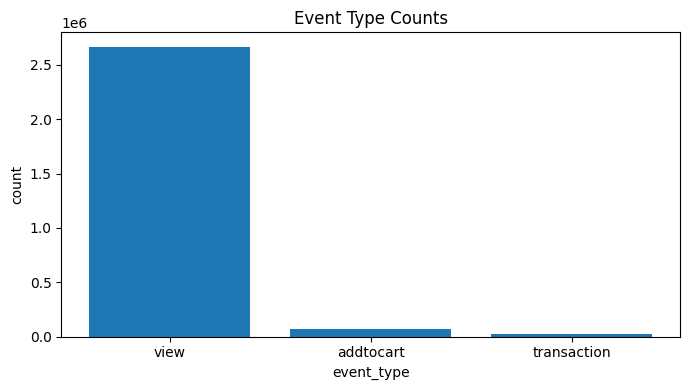

In [4]:
event_counts = interactions["event_type"].value_counts().sort_values(ascending=False)
event_share = (event_counts / len(interactions)).rename("share")

print(event_counts)
print()
print(event_share)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(event_counts.index, event_counts.values)
ax.set_title("Event Type Counts")
ax.set_xlabel("event_type")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Views dominate the dataset by a large margin, while carts and transactions are comparatively rare. That means most collaborative signal comes from weak-intent behavior, which helps explain why simple global popularity can be competitive and why factor models can struggle when the signal-to-noise ratio is low.


## User and Item Cardinality


In [5]:
n_users = interactions["user_id"].nunique()
n_items = interactions["item_id"].nunique()
nnz = len(interactions)
sparsity = nnz / (n_users * n_items)

print(f"users: {n_users:,}")
print(f"items: {n_items:,}")
print(f"interactions: {nnz:,}")
print(f"density estimate (nnz / (n_users * n_items)): {sparsity:.8f}")


users: 1,407,580
items: 235,061
interactions: 2,755,641
density estimate (nnz / (n_users * n_items)): 0.00000833


The user-item matrix is extremely sparse. With well under 0.001% density, any retrieval model that depends on stable user-item co-occurrence patterns has very little support per user, especially for infrequent users.


## Interaction Distribution Per User


In [6]:
interactions_per_user = interactions.groupby("user_id").size()
user_stats = interactions_per_user.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
user_stats


count   1,407,580.0000
mean            1.9577
std            12.5798
min             1.0000
50%             1.0000
75%             2.0000
90%             3.0000
95%             5.0000
99%            13.0000
max         7,757.0000
dtype: float64

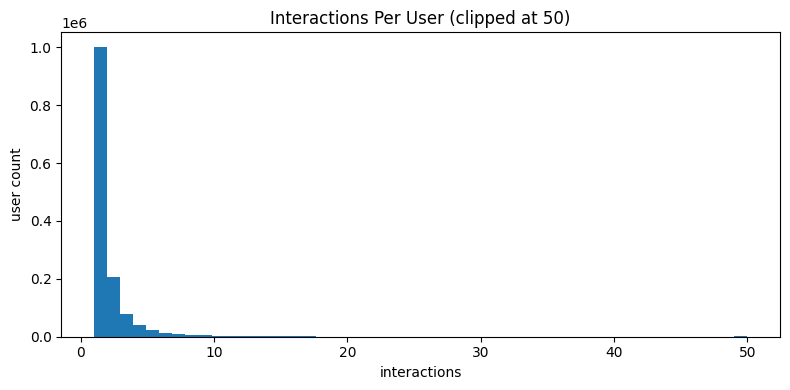

Median interactions per user: 1
95th percentile: 5
99th percentile: 13
Max: 7,757


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(interactions_per_user.clip(upper=50), bins=50)
ax.set_title("Interactions Per User (clipped at 50)")
ax.set_xlabel("interactions")
ax.set_ylabel("user count")
plt.tight_layout()
plt.show()

print(f"Median interactions per user: {interactions_per_user.median():.0f}")
print(f"95th percentile: {interactions_per_user.quantile(0.95):.0f}")
print(f"99th percentile: {interactions_per_user.quantile(0.99):.0f}")
print(f"Max: {interactions_per_user.max():,}")


User activity is highly skewed. The median user has only one interaction, while a very small tail of heavy users accounts for much richer histories. This is a difficult setting for matrix factorization because many users do not provide enough evidence to learn robust latent preferences.


## Interaction Distribution Per Item


In [8]:
interactions_per_item = interactions.groupby("item_id").size()
item_stats = interactions_per_item.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
item_stats


count   235,061.0000
mean         11.7231
std          37.0248
min           1.0000
50%           3.0000
75%           9.0000
90%          25.0000
95%          47.0000
99%         143.0000
max       3,412.0000
dtype: float64

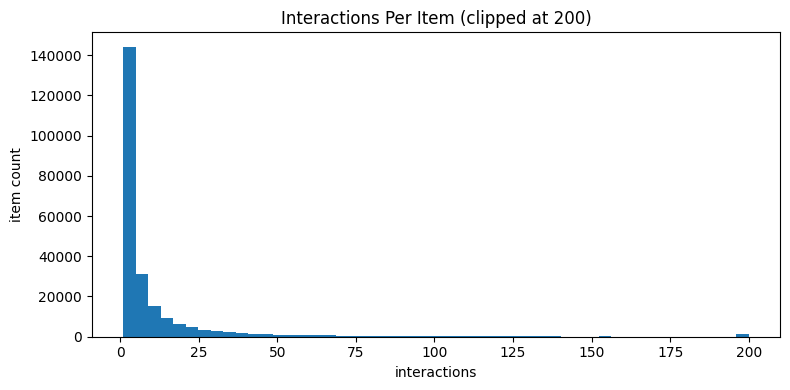

Median interactions per item: 3
95th percentile: 47
99th percentile: 143
Max: 3,412


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(interactions_per_item.clip(upper=200), bins=50)
ax.set_title("Interactions Per Item (clipped at 200)")
ax.set_xlabel("interactions")
ax.set_ylabel("item count")
plt.tight_layout()
plt.show()

print(f"Median interactions per item: {interactions_per_item.median():.0f}")
print(f"95th percentile: {interactions_per_item.quantile(0.95):.0f}")
print(f"99th percentile: {interactions_per_item.quantile(0.99):.0f}")
print(f"Max: {interactions_per_item.max():,}")


Items also follow a long-tail distribution. Most items receive only a handful of events, while a small number of very popular products attract large volumes of traffic. That level of popularity concentration can make a popularity retriever hard to beat in offline evaluation.


## Timestamp Coverage and Activity Over Time


Start timestamp: 2015-05-03 03:00:04.384000+00:00
End timestamp:   2015-09-18 02:59:47.788000+00:00
Active days:     139


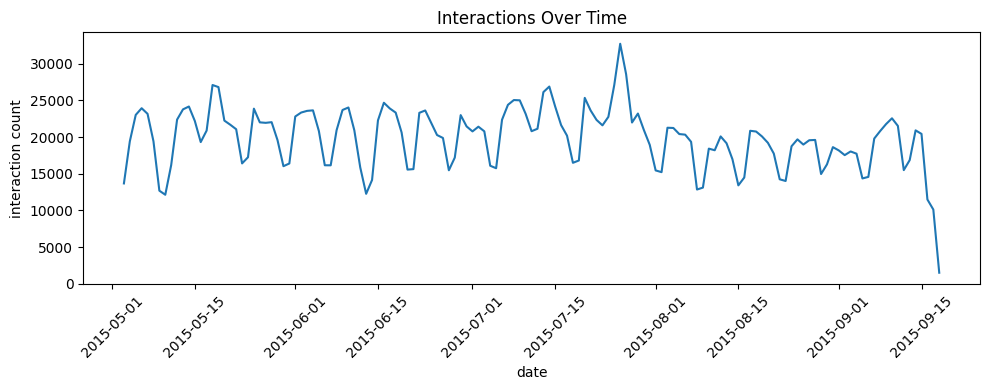

In [10]:
print(f"Start timestamp: {interactions['timestamp'].min()}")
print(f"End timestamp:   {interactions['timestamp'].max()}")
print(f"Active days:     {interactions['timestamp'].dt.floor('D').nunique()}")

daily_activity = (
    interactions.assign(date=interactions["timestamp"].dt.floor("D"))
    .groupby("date")
    .size()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily_activity.index, daily_activity.values)
ax.set_title("Interactions Over Time")
ax.set_xlabel("date")
ax.set_ylabel("interaction count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The processed data spans May to September 2015 and shows steady daily activity with some variation. The splits are chronological, which is the correct setup for offline recommendation evaluation because it prevents future leakage into training.


## Train / Val / Test Split Summary


In [11]:
split_summary = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(df),
            "row_share": len(df) / len(interactions),
            "users": df["user_id"].nunique(),
            "items": df["item_id"].nunique(),
            "start_ts": df["timestamp"].min(),
            "end_ts": df["timestamp"].max(),
        }
        for name, df in [("train", train), ("val", val), ("test", test)]
    ]
)
split_summary


,split,rows,row_share,users,items,start_ts,end_ts
0,train,2204512,0.8000,1123765,212915,2015-05-03 03:00:04.384000+00:00,2015-08-18 04:23:01.129000+00:00
1,val,275564,0.1000,156954,77696,2015-08-18 04:23:20.445000+00:00,2015-09-02 17:49:11.563000+00:00
2,test,275565,0.1000,158020,77507,2015-09-02 17:49:14.032000+00:00,2015-09-18 02:59:47.788000+00:00


The train split contains most of the interaction mass, while validation and test are smaller forward-looking windows. Validation and test also contain fewer distinct items than the full interaction set, which is typical when later windows expose only a subset of the historical catalog.


## User-Item Sparsity Estimate


In [12]:
sparsity_summary = pd.DataFrame(
    {
        "metric": ["users", "items", "observed interactions", "density estimate"],
        "value": [n_users, n_items, nnz, sparsity],
    }
)
sparsity_summary


,metric,value
0,users,"1,407,580.0000"
1,items,"235,061.0000"
2,observed interactions,"2,755,641.0000"
3,density estimate,0.0000


This density estimate is a simple but important sanity check. The interaction graph is so sparse that removing weak signals and keeping only stronger events would make the graph even thinner, which matches the repository's observation that filtering to carts and purchases degraded ALS further.


## Top Popular Items


In [13]:
top_items = interactions["item_id"].value_counts().head(20)
top_items_df = top_items.rename_axis("item_id").reset_index(name="interaction_count")
top_items_df


,item_id,interaction_count
0,187946,3412
1,461686,2975
2,5411,2334
3,370653,1854
4,219512,1800
5,257040,1647
6,298009,1642
7,96924,1633
8,309778,1628
9,384302,1608


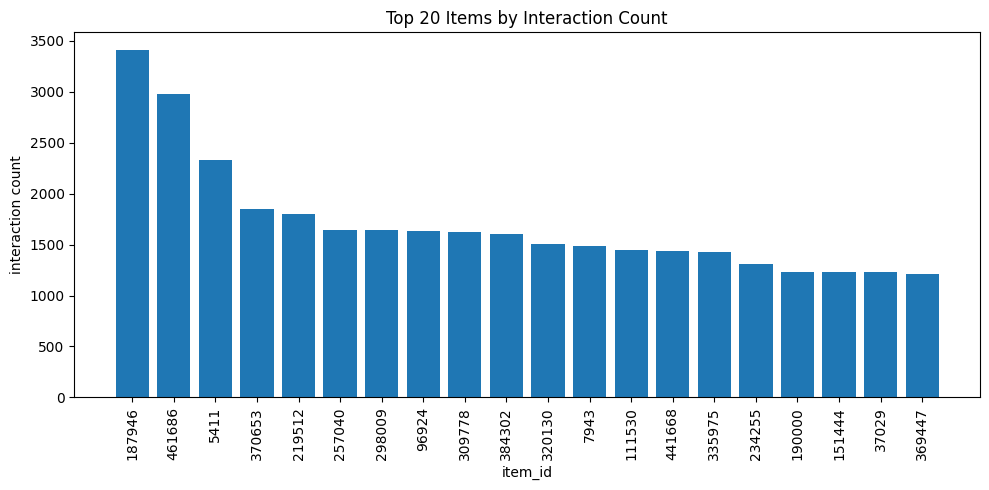

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_items_df["item_id"].astype(str), top_items_df["interaction_count"])
ax.set_title("Top 20 Items by Interaction Count")
ax.set_xlabel("item_id")
ax.set_ylabel("interaction count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


The head of the item popularity distribution is very pronounced. When a small set of items consistently appears in many user histories, a popularity-based candidate generator can achieve reasonable recall even without personalization.


## Key Observations

- Views dominate the dataset, so most implicit feedback is weak-intent rather than high-intent.
- Interaction counts per user and per item are highly skewed, with a long tail and many very small histories.
- The user-item matrix is extremely sparse, which makes collaborative retrieval hard and brittle.
- Strong-signal filtering would reduce noise, but it also reduces graph connectivity and can hurt factor models further.
- Heavy popularity concentration helps explain why the popularity baseline performed well in retrieval.


## Why These Properties Matter for Recommendation Modeling

The repository reports that the popularity retriever achieved a higher Recall@10 than both item-KNN and ALS on validation, while the final LightGBM ranker improved Recall@10 substantially further. The EDA above makes that result plausible rather than surprising.

First, strong popularity skew means many users are exposed to the same small set of frequently interacted items, so a non-personalized popularity baseline can already capture a useful share of relevant items. Second, extreme sparsity and one-event user histories make it hard for ALS to learn stable latent structure, especially when views dominate the matrix and add noisy weak-intent interactions. Finally, these conditions motivate a ranking stage: retrieval alone is too coarse, but a ranker can combine popularity, interaction history, and other engineered features to sort weak signals into much better final recommendations.
